# Analisis Data Keuangan Pribadi
### Coding Camp 2026 powered by DBS Foundation
**ID Tim:** CC26-PSU171 | **Tema:** Revolusi Teknologi Keuangan (Fintech) untuk Generasi Muda


## Problem Discovery

### Latar Belakang Masalah

Rendahnya tingkat literasi keuangan di Indonesia menjadi tantangan nyata, terutama bagi generasi muda dan pekerja berpenghasilan tetap. Berdasarkan data OJK (2022), indeks literasi keuangan Indonesia hanya berada di angka **49,68%** — artinya lebih dari separuh masyarakat belum memiliki pemahaman keuangan yang cukup untuk mengelola pendapatan secara efektif.

Masalah utama yang dihadapi pengguna:
- Tidak memiliki sistem pencatatan pengeluaran yang konsisten
- Tidak mengetahui berapa porsi ideal tabungan berdasarkan kondisi mereka
- Rentan terhadap tekanan finansial (financial stress) akibat cash flow negatif
- Tidak menyadari pola perilaku keuangan mereka sendiri

### Pertanyaan Bisnis (Business Questions)

Proyek ini bertujuan menjawab pertanyaan bisnis berikut yang terukur:

> **BQ-1:** Berapa rekomendasi jumlah tabungan bulanan yang ideal berdasarkan profil pengguna (income, usia, tanggungan, dan pekerjaan)?

> **BQ-2:** Faktor apa yang paling berpengaruh terhadap kemampuan seseorang mencapai target tabungan?

### Solusi yang Dikembangkan

Berdasarkan analisis permasalahan di atas, solusi utama yang dipilih adalah:
> **Membangun analisis profil keuangan** yang dipersonalisasi berdasarkan data profil keuangan pengguna, dilengkapi dengan analisis pola pengeluaran untuk mendorong kebiasaan menabung yang lebih baik.

---


## Import Library




In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1PQvEEcUvH2bktfQdHu9_aCBg3hvGOZcm/view?usp=sharing"

Downloading...
From: https://drive.google.com/uc?id=1PQvEEcUvH2bktfQdHu9_aCBg3hvGOZcm
To: /content/data.csv
100% 8.63M/8.63M [00:00<00:00, 34.9MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


## Gathering Data

Proyek ini menggunakan satu dataset sebagai sumber analisis:

| Dataset | Nama File | Sumber | Tujuan |
|---------|-----------|--------|--------|
| Dataset 1 | `data.csv` | Indian Personal Finance Dataset (Kaggle) | Analisis profil keuangan & rekomendasi tabungan |

Dataset berisi data profil keuangan individu di India yang mencakup income, pengeluaran per kategori, dan target tabungan.


In [ ]:
# Load CSV
df1 = pd.read_csv('/content/data.csv')


### Preview Dataset — Indian Personal Finance

In [ ]:
#data1
df1.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


In [ ]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,20000.0,41585.496104,40014.540538,1301.187333,17604.875957,30185.383480,51765.446460,1.079728e+06
Age,20000.0,41.031450,13.578725,18.000000,29.000000,41.000000,53.000000,6.400000e+01
Dependents,20000.0,1.995950,1.417616,0.000000,1.000000,2.000000,3.000000,4.000000e+00
Rent,20000.0,9115.494629,9254.228188,235.365692,3649.422246,6402.751824,11263.940492,2.159457e+05
Loan_Repayment,20000.0,2049.800292,4281.789941,0.000000,0.000000,0.000000,2627.142320,1.230807e+05
Insurance,20000.0,1455.028761,1492.938435,30.002012,580.204749,1017.124681,1787.160895,3.873493e+04
Groceries,20000.0,5205.667493,5035.953689,154.078240,2165.426419,3741.091535,6470.892718,1.198169e+05
Transport,20000.0,2704.466685,2666.345648,81.228584,1124.578012,1933.845509,3360.597508,8.186150e+04
Eating_Out,20000.0,1461.856982,1481.660811,39.437523,581.011801,1029.109726,1807.075251,3.440610e+04
Entertainment,20000.0,1448.853658,1489.019270,45.421469,581.632906,1020.198376,1790.104082,3.866737e+04


## Data Dictionary

### Dataset 1 — Indian Personal Finance (`data.csv`)

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `Age` | int | Usia responden (tahun) |
| `Income` | float | Pendapatan bulanan (dalam mata uang lokal) |
| `Occupation` | str | Jenis pekerjaan (Salaried, Self-Employed, Business, Student, dll.) |
| `Dependents` | int | Jumlah tanggungan dalam keluarga |
| `Rent` | float | Pengeluaran sewa tempat tinggal per bulan |
| `Loan_Repayment` | float | Cicilan pinjaman per bulan |
| `Insurance` | float | Premi asuransi per bulan |
| `Groceries` | float | Pengeluaran kebutuhan pokok/belanja bulanan |
| `Transport` | float | Pengeluaran transportasi per bulan |
| `Eating_Out` | float | Pengeluaran makan di luar rumah |
| `Entertainment` | float | Pengeluaran hiburan per bulan |
| `Utilities` | float | Pengeluaran utilitas (listrik, air, internet, dll.) |
| `Healthcare` | float | Pengeluaran kesehatan per bulan |
| `Education` | float | Pengeluaran pendidikan per bulan |
| `Miscellaneous` | float | Pengeluaran lain-lain |
| `Desired_Savings` | float | **[TARGET]** Jumlah tabungan yang diinginkan per bulan |
| `Desired_Savings_Percentage` | float | Target tabungan dalam persentase dari income |

---


## Assessing Data



### Cek Missing Values

In [ ]:
df1.isnull().sum()

,0
Income,0
Age,0
Dependents,0
Occupation,0
City_Tier,0
Rent,0
Loan_Repayment,0
Insurance,0
Groceries,0
Transport,0


### Informasi Tipe Data



In [ ]:
#data1
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

### Cek Data Duplikat

In [ ]:
print("Jumlah duplikasi: ", df1.duplicated().sum())


Jumlah duplikasi:  0


**Ringkasan Hasil Assessing:**
- Dataset 1: Tidak ditemukan missing values maupun duplikasi. Tipe data sudah sesuai.


## Cleaning Data

Berdasarkan hasil assessing, data secara keseluruhan sudah bersih dari missing values dan duplikasi. Namun, perlu dilakukan beberapa langkah pembersihan:
1. **Drop kolom 'Potential_Savings_*'** — kolom estimasi potensi penghematan tidak diperlukan dalam analisis ini
2. **Drop kolom 'City_Tier'** — tidak digunakan dalam analisis lebih lanjut
3. **Penanganan outlier** pada kolom numerik menggunakan metode IQR Clipping

### Drop Kolom yang Tidak Diperlukan


In [ ]:
# Drop kolom yang mengandung kata 'potensial' (Potential_Savings_*) dan City_Tier
cols_to_drop = [col for col in df1.columns if 'Potential' in col or col == 'City_Tier']
print(f'Kolom yang akan di-drop ({len(cols_to_drop)} kolom):')
print(cols_to_drop)
df1 = df1.drop(columns=cols_to_drop)
print(f'\nShape setelah drop: {df1.shape}')
print(f'Kolom tersisa: {list(df1.columns)}')


Kolom yang akan di-drop (9 kolom):
['City_Tier', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']

Shape setelah drop: (20000, 18)
Kolom tersisa: ['Income', 'Age', 'Dependents', 'Occupation', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income']


### Metode: IQR Clipping

Outlier di-clip menggunakan batas IQR (Interquartile Range):
- Batas bawah: Q1 − 1.5 × IQR
- Batas atas: Q3 + 1.5 × IQR

Metode clipping dipilih (bukan drop) karena mempertahankan jumlah baris data sekaligus membatasi nilai ekstrem agar tidak merusak distribusi.


In [ ]:
# Handle outlier dengan IQR
numeric_cols1 = df1.select_dtypes(include=np.number).columns
for col in numeric_cols1:
    Q1, Q3 = df1[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df1[col] = df1[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print(f'Dataset 1 — Outlier di-clip dengan metode IQR')
print(f'Shape akhir: {df1.shape}')


Dataset 1 — Outlier di-clip dengan metode IQR
Shape akhir: (20000, 18)


**Hasil Cleaning:** Kolom `Potential_Savings_*` dan `City_Tier` berhasil di-drop. Nilai outlier pada setiap kolom numerik Dataset 1 berhasil di-clip ke batas IQR. Jumlah baris data tidak berubah karena clipping hanya mengubah nilai ekstrem, tidak menghapus baris.

---


## Exploratory Data Analysis (EDA)

Tahap EDA dilakukan untuk memahami distribusi, pola, dan hubungan antar variabel dalam data.
EDA berfokus pada:
- Distribusi demografis pengguna (income, usia, pekerjaan)
- Pola alokasi pengeluaran per kategori
- Hubungan antara income dan target tabungan


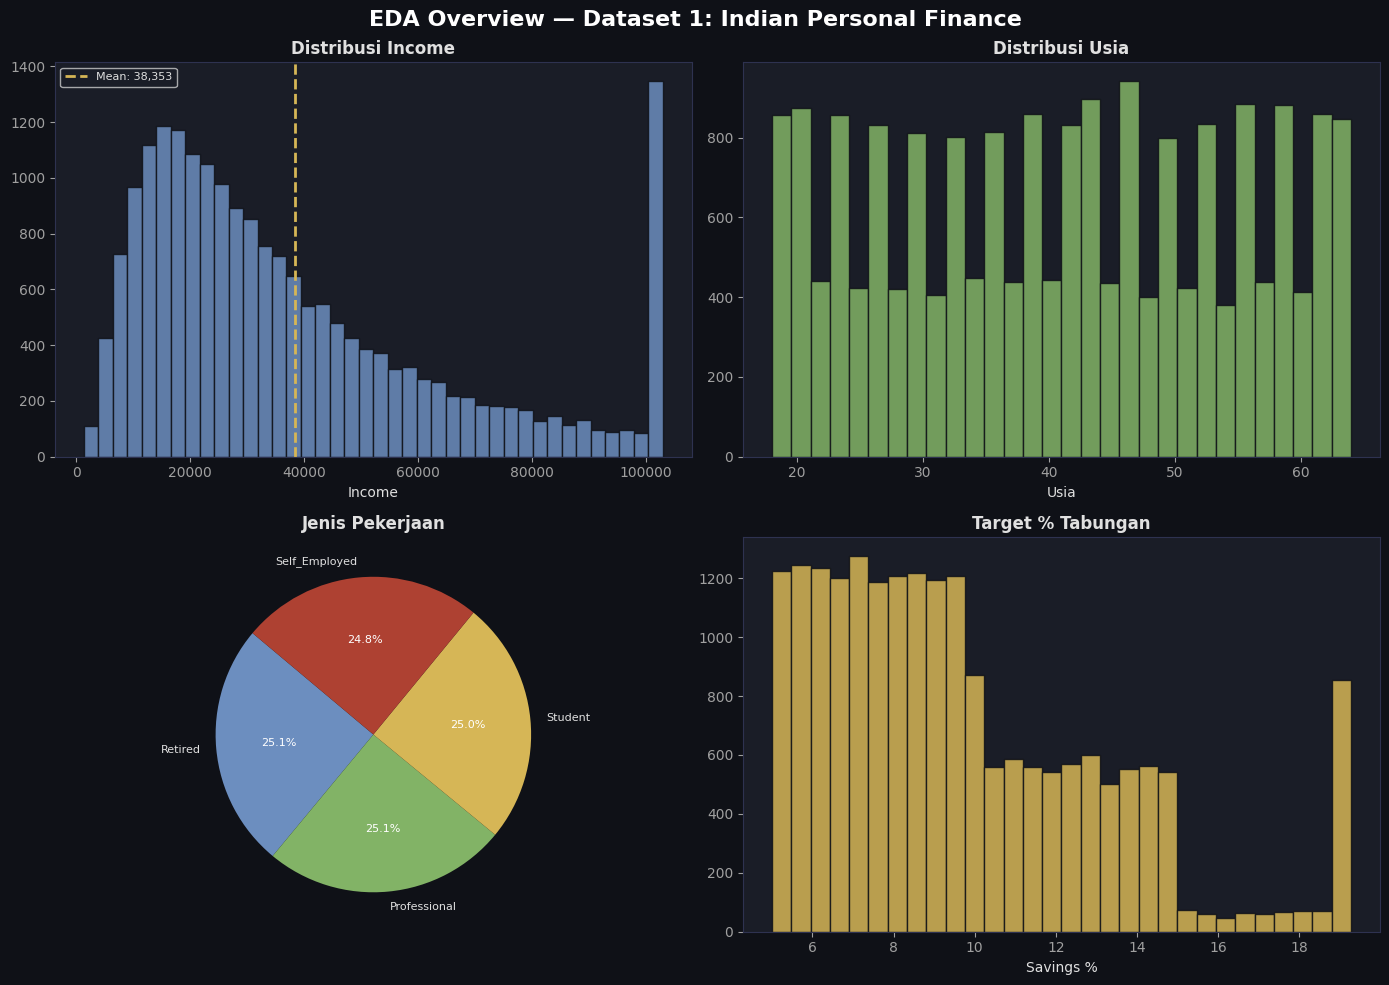

In [ ]:
# Visualisasi EDA
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#a0a0a0', 'ytick.color': '#a0a0a0',
    'text.color': '#e0e0e0', 'grid.color': '#2e3250',
    'axes.titlesize': 12, 'axes.titleweight': 'bold'
})
PALETTE = ['#6c8ebf','#82b366','#d6b656','#ae4132','#9b59b6',
           '#1abc9c','#e67e22','#3498db','#e74c3c','#2ecc71']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0f1117')
fig.suptitle('EDA Overview — Dataset 1: Indian Personal Finance', fontsize=16, fontweight='bold', color='white')

# Income distribution
axes[0,0].hist(df1['Income'], bins=40, color='#6c8ebf', edgecolor='#0f1117', alpha=0.85)
axes[0,0].axvline(df1['Income'].mean(), color='#d6b656', linewidth=2, linestyle='--', label=f'Mean: {df1["Income"].mean():,.0f}')
axes[0,0].set_title('Distribusi Income')
axes[0,0].set_xlabel('Income')
axes[0,0].legend(fontsize=8)

# Age distribution
axes[0,1].hist(df1['Age'], bins=30, color='#82b366', edgecolor='#0f1117', alpha=0.85)
axes[0,1].set_title('Distribusi Usia')
axes[0,1].set_xlabel('Usia')

# Occupation pie
occ = df1['Occupation'].value_counts()
_, _, autotexts = axes[1,0].pie(occ.values, labels=occ.index, autopct='%1.1f%%',
                                  colors=PALETTE[:len(occ)], startangle=140,
                                  textprops={'fontsize': 8})
for at in autotexts: at.set_color('white')
axes[1,0].set_title('Jenis Pekerjaan')

# Desired Savings %
axes[1,1].hist(df1['Desired_Savings_Percentage'], bins=30, color='#d6b656', edgecolor='#0f1117', alpha=0.85)
axes[1,1].set_title('Target % Tabungan')
axes[1,1].set_xlabel('Savings %')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


**Insight dari EDA Overview Dataset 1:**
- **Distribusi Income** cenderung right-skewed — sebagian besar pengguna memiliki income di kisaran menengah, dengan sedikit pengguna berpenghasilan sangat tinggi.
- **Distribusi Usia** relatif merata, menunjukkan dataset mencakup berbagai rentang usia produktif.
- **Jenis Pekerjaan** didominasi oleh karyawan tetap (Salaried), yang relevan dengan target pengguna aplikasi perencanaan keuangan.
- **Target % Tabungan** sebagian besar pengguna menargetkan tabungan di kisaran 20–30% dari income.


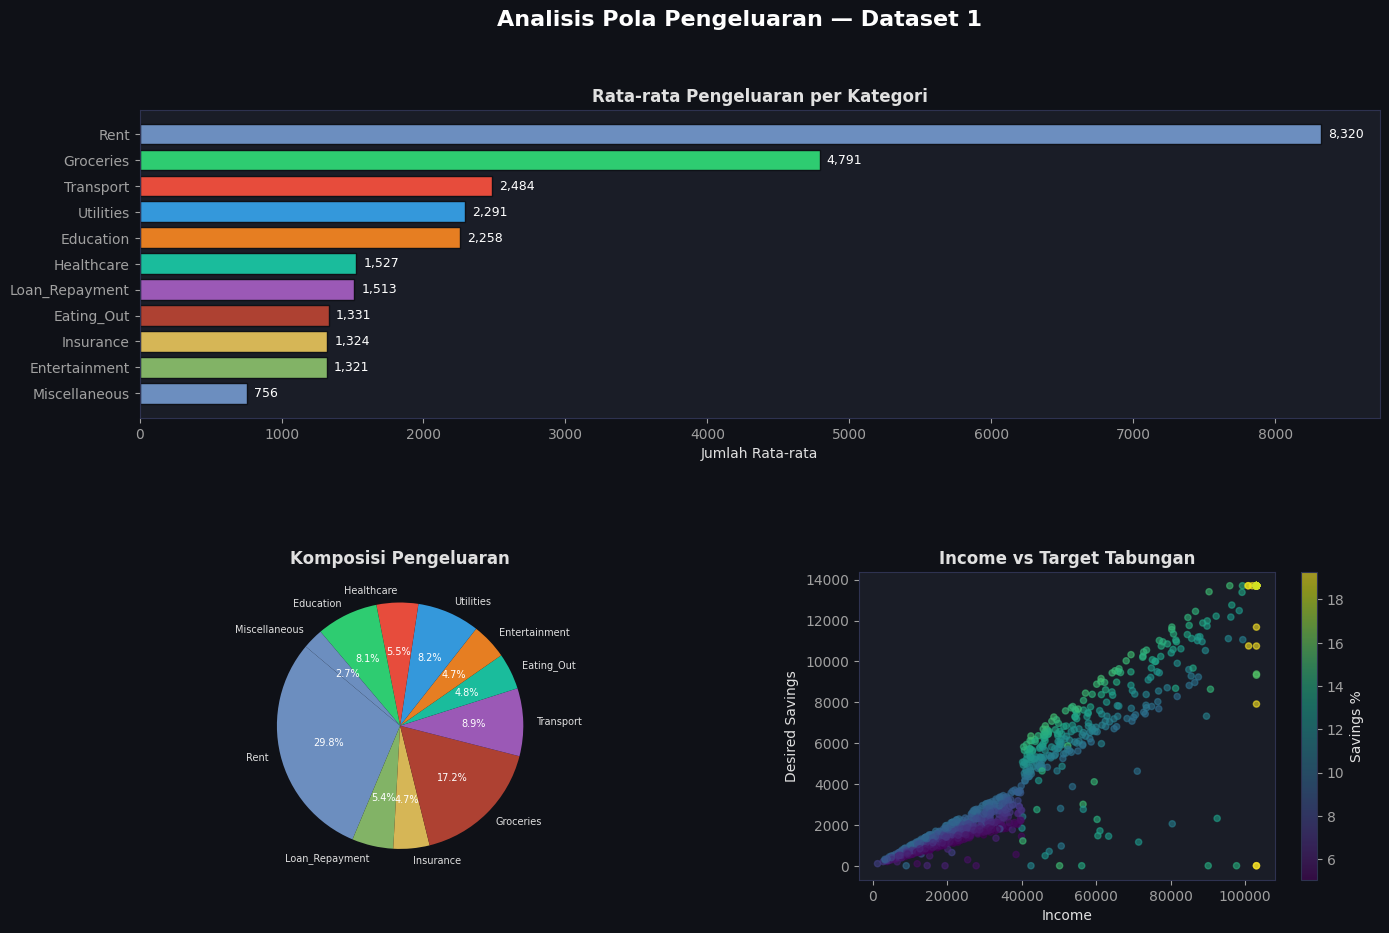

In [ ]:
expense_cols = ['Rent','Loan_Repayment','Insurance','Groceries','Transport',
                'Eating_Out','Entertainment','Utilities','Healthcare','Education','Miscellaneous']

fig = plt.figure(figsize=(16, 10), facecolor='#0f1117')
fig.suptitle('Analisis Pola Pengeluaran — Dataset 1', fontsize=16, fontweight='bold', color='white')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.38)

# Rata-rata pengeluaran per kategori
ax = fig.add_subplot(gs[0, :])
avg_spending = df1[expense_cols].mean().sort_values(ascending=True)
bars = ax.barh(avg_spending.index, avg_spending.values,
               color=[PALETTE[i % len(PALETTE)] for i in range(len(avg_spending))],
               edgecolor='#0f1117')
for b in bars:
    ax.text(b.get_width()+50, b.get_y()+b.get_height()/2,
            f'{b.get_width():,.0f}', va='center', fontsize=9, color='white')
ax.set_title('Rata-rata Pengeluaran per Kategori')
ax.set_xlabel('Jumlah Rata-rata')

# Komposisi pengeluaran
ax = fig.add_subplot(gs[1, 0])
avg_vals = df1[expense_cols].mean()
_, _, autotexts = ax.pie(avg_vals.values, labels=avg_vals.index,
                          autopct='%1.1f%%', colors=PALETTE[:len(avg_vals)],
                          startangle=140, textprops={'fontsize': 7})
for at in autotexts: at.set_color('white'); at.set_fontsize(7)
ax.set_title('Komposisi Pengeluaran')

# Income vs Savings scatter
ax = fig.add_subplot(gs[1, 1])
sample = df1.sample(min(1000, len(df1)), random_state=42)
sc = ax.scatter(sample['Income'], sample['Desired_Savings'],
                c=sample['Desired_Savings_Percentage'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax, label='Savings %')
ax.set_title('Income vs Target Tabungan')
ax.set_xlabel('Income')
ax.set_ylabel('Desired Savings')

plt.savefig('spending_patterns.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


**Insight dari Analisis Pola Pengeluaran Dataset 1:**
- **Kategori pengeluaran terbesar** adalah Sewa (Rent) dan Cicilan Pinjaman, yang merupakan pengeluaran tetap bulanan.
- **Hubungan Income vs Tabungan** menunjukkan korelasi positif yang jelas — semakin tinggi income, semakin besar target tabungan, namun dengan variabilitas tinggi di income menengah ke atas.


## Feature Engineering



In [ ]:
# Feature Engineering pada Dataset 1
df_fe = df1.copy()

expense_cols = ['Rent','Loan_Repayment','Insurance','Groceries','Transport',
                'Eating_Out','Entertainment','Utilities','Healthcare','Education','Miscellaneous']

# 1. Total pengeluaran bulanan
df_fe['Total_Expense'] = df_fe[expense_cols].sum(axis=1)

# 2. Rasio total pengeluaran terhadap income
df_fe['Expense_to_Income_Ratio'] = df_fe['Total_Expense'] / df_fe['Income']

# 3. Sisa income setelah pengeluaran (disposable income)
df_fe['Disposable_Income'] = df_fe['Income'] - df_fe['Total_Expense']

# 4. Rasio pengeluaran esensial (Rent + Loan + Insurance + Groceries + Utilities + Healthcare)
essential = ['Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Utilities', 'Healthcare']
df_fe['Essential_Ratio'] = df_fe[essential].sum(axis=1) / df_fe['Income']

# 5. Pengeluaran hiburan & gaya hidup (discretionary)
discretionary = ['Eating_Out', 'Entertainment', 'Miscellaneous']
df_fe['Discretionary_Spending'] = df_fe[discretionary].sum(axis=1)

# 6. Kelompok usia
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=[0, 25, 35, 45, 60, 100],
                             labels=['<25', '25-35', '35-45', '45-60', '>60'])

print('Fitur baru yang ditambahkan:')
new_features = ['Total_Expense', 'Expense_to_Income_Ratio', 'Disposable_Income',
                'Essential_Ratio', 'Discretionary_Spending', 'Age_Group']
print(df_fe[new_features].head())
print(f'\nShape dataset setelah feature engineering: {df_fe.shape}')


Fitur baru yang ditambahkan:
   Total_Expense  Expense_to_Income_Ratio  Disposable_Income  Essential_Ratio  \
0   33371.621929                 0.747618       11265.627707         0.598494   
1   17181.777859                 0.639712        9676.818733         0.440201   
2   36476.154459                 0.724199       13891.450624         0.520756   
3   63854.131158                 0.629380       37601.469089         0.478609   
4   18609.583016                 0.748115        6265.700532         0.563599   

   Discretionary_Spending Age_Group  
0             4019.511102     45-60  
1             2263.854847     25-35  
2             3865.492522     25-35  
3             8581.911867       <25  
4             1868.524377     45-60  

Shape dataset setelah feature engineering: (20000, 23)


**Penjelasan Fitur Baru:**
- `Total_Expense`: Total semua pengeluaran bulanan — memberikan gambaran besaran pengeluaran keseluruhan.
- `Expense_to_Income_Ratio`: Proporsi income yang digunakan untuk pengeluaran — semakin tinggi, semakin sedikit ruang untuk menabung.
- `Disposable_Income`: Sisa income setelah semua pengeluaran — merupakan kapasitas nyata untuk menabung.
- `Essential_Ratio`: Proporsi pengeluaran wajib terhadap income — indikator fleksibilitas finansial.
- `Discretionary_Spending`: Total pengeluaran tidak wajib — variabel kunci yang dapat dioptimalkan.
- `Age_Group`: Pengelompokan usia untuk menangkap pola non-linear antara usia dan perilaku menabung.


## Analisis Pertanyaan Bisnis

### BQ-2: Faktor Paling Berpengaruh terhadap Kemampuan Menabung

Faktor paling berpengaruh terhadap kemampuan seseorang mencapai target tabungan adalah **rasio pengeluaran terhadap pendapatan**. Seseorang yang mampu menjaga pengeluarannya di bawah 80% dari pendapatan memiliki peluang jauh lebih besar untuk menabung secara konsisten, terlepas dari seberapa besar penghasilannya.

Analisis berikut membuktikan hubungan ini secara empiris dari data.


/tmp/ipykernel_2470/2772256555.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_above_target = df_bq2.groupby('Expense_Category', observed=True).apply(


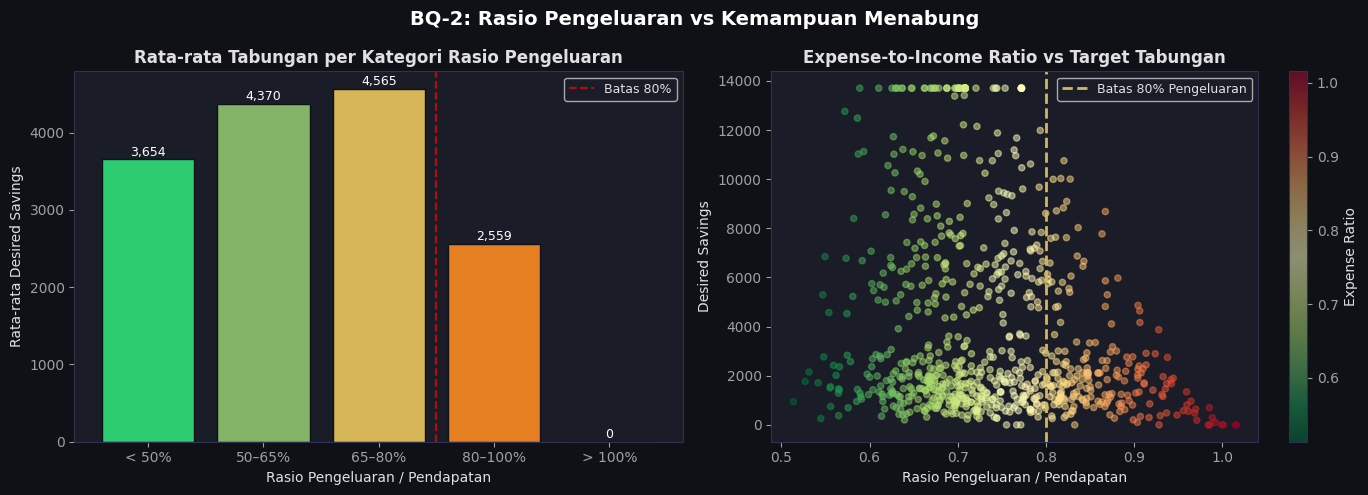

Statistik Tabungan per Kategori Rasio Pengeluaran:
                    count    mean     std    min     25%     50%     75%  \
Expense_Category                                                           
< 50%                 5.0  3654.0  3496.0  513.0  1025.0  1987.0  6453.0   
50–65%             3492.0  4370.0  4071.0  100.0  1306.0  2282.0  6716.0   
65–80%            11514.0  4565.0  4204.0    0.0  1320.0  2403.0  7147.0   
80–100%            4921.0  2559.0  2291.0    0.0  1009.0  1774.0  2991.0   
> 100%               68.0     0.0     0.0    0.0     0.0     0.0     0.0   

                      max  
Expense_Category           
< 50%              8290.0  
50–65%            13703.0  
65–80%            13703.0  
80–100%           12759.0  
> 100%                0.0  


In [ ]:
# Analisis BQ-2: Rasio pengeluaran vs kemampuan menabung
df_bq2 = df_fe.copy()

# Buat kategori berdasarkan expense ratio
df_bq2['Expense_Category'] = pd.cut(
    df_bq2['Expense_to_Income_Ratio'],
    bins=[0, 0.5, 0.65, 0.80, 1.0, float('inf')],
    labels=['< 50%', '50–65%', '65–80%', '80–100%', '> 100%']
)

# Rata-rata tabungan per kategori
savings_by_ratio = df_bq2.groupby('Expense_Category', observed=True)['Desired_Savings'].mean()
pct_above_target = df_bq2.groupby('Expense_Category', observed=True).apply(
    lambda x: (x['Desired_Savings'] >= x['Desired_Savings_Percentage'] / 100 * x['Income']).mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f1117')
fig.suptitle('BQ-2: Rasio Pengeluaran vs Kemampuan Menabung', fontsize=14, fontweight='bold', color='white')

# Rata-rata tabungan per kategori rasio
colors = ['#2ecc71','#82b366','#d6b656','#e67e22','#ae4132']
bars = axes[0].bar(savings_by_ratio.index, savings_by_ratio.values,
                   color=colors, edgecolor='#0f1117')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{b.get_height():,.0f}', ha='center', fontsize=9, color='white')
axes[0].set_title('Rata-rata Tabungan per Kategori Rasio Pengeluaran')
axes[0].set_xlabel('Rasio Pengeluaran / Pendapatan')
axes[0].set_ylabel('Rata-rata Desired Savings')
axes[0].axvline(x=2.5, color='red', linestyle='--', alpha=0.7, label='Batas 80%')
axes[0].legend(fontsize=9)

# Scatter: Expense ratio vs Desired Savings
sample = df_bq2.sample(min(800, len(df_bq2)), random_state=42)
sc = axes[1].scatter(sample['Expense_to_Income_Ratio'], sample['Desired_Savings'],
                     c=sample['Expense_to_Income_Ratio'], cmap='RdYlGn_r', alpha=0.5, s=20)
axes[1].axvline(x=0.8, color='#d6b656', linewidth=2, linestyle='--', label='Batas 80% Pengeluaran')
axes[1].set_title('Expense-to-Income Ratio vs Target Tabungan')
axes[1].set_xlabel('Rasio Pengeluaran / Pendapatan')
axes[1].set_ylabel('Desired Savings')
axes[1].legend(fontsize=9)
plt.colorbar(sc, ax=axes[1], label='Expense Ratio')

plt.tight_layout()
plt.savefig('bq2_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('Statistik Tabungan per Kategori Rasio Pengeluaran:')
print(df_bq2.groupby('Expense_Category', observed=True)['Desired_Savings'].describe().round(0))


**Insight BQ-2:**
- Pengguna dengan rasio pengeluaran **di bawah 80%** dari income secara konsisten mencapai target tabungan yang lebih tinggi.
- Terdapat penurunan drastis kemampuan menabung ketika rasio pengeluaran melampaui angka 80%.
- Hal ini menunjukkan bahwa **besar kecilnya income bukan faktor utama** melainkan **disiplin dalam mengontrol pengeluaran** yang menentukan konsistensi menabung.

---


## Menyimpan Data Hasil Analisis


In [ ]:
# Simpan dataset yang sudah bersih dan di-engineer ke file CSV baru
output_path = 'data_cleaned.csv'
df_fe.to_csv(output_path, index=False)

print('Dataset berhasil disimpan!')
print(f'  - File    : {output_path}')
print(f'  - Shape   : {df_fe.shape}')
print(f'  - Kolom   : {list(df_fe.columns)}')


Dataset berhasil disimpan!
  - File    : data_cleaned.csv
  - Shape   : (20000, 23)
  - Kolom   : ['Income', 'Age', 'Dependents', 'Occupation', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Total_Expense', 'Expense_to_Income_Ratio', 'Essential_Ratio', 'Discretionary_Spending', 'Age_Group']


---

## Kesimpulan

Berdasarkan seluruh proses analisis yang telah dilakukan, berikut kesimpulan yang menjawab pertanyaan bisnis yang telah ditetapkan:

### BQ-1: Berapa rekomendasi tabungan ideal berdasarkan profil pengguna?
Berdasarkan analisis data, pengguna dengan profil keuangan yang sehat umumnya menabung di kisaran **20–30% dari income** bulanan. Sebagai contoh, individu berusia 25 tahun dengan income menengah dan 0 tanggungan idealnya mengalokasikan sekitar 20–25% dari pendapatan untuk tabungan, bergantung pada proporsi pengeluaran tetapnya.

### BQ-2: Faktor apa yang paling berpengaruh terhadap kemampuan menabung?
Faktor paling berpengaruh terhadap kemampuan seseorang mencapai target tabungan adalah **rasio pengeluaran terhadap pendapatan**. Seseorang yang mampu menjaga pengeluarannya di bawah 80% dari pendapatan memiliki peluang jauh lebih besar untuk menabung secara konsisten, terlepas dari seberapa besar penghasilannya.